In [1]:
import os
os.chdir('/workspace/d91c054a-e339-4ca8-abcb-0fc9bf110f36')
os.listdir('.')


['memory', '.prompts', '.kernel_llm_logs_1.txt', '.config', 'ldh_def.py']

In [2]:
import subprocess
# Search for the relevant files in /workspace
result = subprocess.run(['find', '/workspace', '-maxdepth', '5', '-name', '*.npy', '-o', '-name', 'r13*', '-o', '-name', '*fourth*moment*'], capture_output=True, text=True)
print(result.stdout[:5000])
print('STDERR:', result.stderr[:2000])



STDERR: find: ‘/workspace/lost+found’: Permission denied



In [3]:
result = subprocess.run(['ls', '/workspace'], capture_output=True, text=True)
print(result.stdout)


d91c054a-e339-4ca8-abcb-0fc9bf110f36
lost+found



In [4]:
from e14c.subagents import list_tasks
print(list_tasks(limit=50))


21f4d35a-6b64-4363-9f40-c423899c6920 in progress 2026-05-31T07:31:21.584256Z 
Here is some information on the dataset you will be analyzing:
<primary-dataset
d91c054a-e339-4ca8-abcb-0fc9bf110f36 in progress 2026-05-31T07:31:21.541847Z 
Here is some information on the dataset you will be analyzing:
<primary-dataset
e9a6b3ae-12a5-441e-9840-35c70e32d255 in progress 2026-05-31T07:31:21.506076Z 
Here is some information on the dataset you will be analyzing:
<primary-dataset
ac2eac57-9c59-4f26-a873-d1ba1c4b7b5c in progress 2026-05-31T07:31:21.492029Z 
Here is some information on the dataset you will be analyzing:
<primary-dataset
8c50938a-4e3e-4a69-89c9-0648c02d1679 success 2026-05-31T06:36:18.594570Z 
Here is some information on the dataset you will be analyzing:
<primary-dataset
41fabbde-1949-4038-b312-35dc9ba94934 success 2026-05-31T06:36:18.546791Z 
Here is some information on the dataset you will be analyzing:
<primary-dataset
c7eacfb8-052d-4c79-89db-dce9cc4b7e1d success 2026-05-31T06:3

In [5]:
from e14c.data_storage import list_project_tags, list_entries_by_tag, search
tags = list_project_tags()
print(tags)


['heron_output']


In [6]:
entries = list_entries_by_tag('heron_output')
print(len(entries))
for e in entries[:50]:
 print(e.get('name'), '|', e.get('entry_id'), '|', (e.get('description') or '')[:100])


200
c7eacfb8-052d-4c79-89db-dce9cc4b7e1d.ipynb | None | 
c7eacfb8-052d-4c79-89db-dce9cc4b7e1d_memory_heron_c0_20260531T063624465234.jsonl | None | 
ldh_fast_eval.cpython-313.pyc | None | 
ldh_ckpt_00250_meta.json | None | 
ldh_ckpt_01250_meta.json | None | 
ldh_ckpt_00250.npy | None | 
ldh_ckpt_02000_meta.json | None | 
ldh_ckpt_00750.npy | None | 
ldh_ckpt_01000.npy | None | 
ldh_ckpt_01250.npy | None | 
ldh_ckpt_02500_meta.json | None | 
ldh_ckpt_01500_meta.json | None | 
ldh_ckpt_00750_meta.json | None | 
ldh_ckpt_01500.npy | None | 
ldh_ckpt_00500_meta.json | None | 
ldh_ckpt_02500.npy | None | 
ldh_ckpt_01750.npy | None | 
ldh_ckpt_02000.npy | None | 
ldh_ckpt_01750_meta.json | None | 
ldh_ckpt_02250.npy | None | 
ldh_ckpt_02250_meta.json | None | 
ldh_ckpt_01000_meta.json | None | 
ldh_ckpt_00500.npy | None | 
generate_ldh_zeros.py | None | 
run_log.txt | None | 
script_stdout.log | None | 
step032_msg001_img000.png | None | 
41fabbde-1949-4038-b312-35dc9ba94934_memory_heron_c0_2

In [7]:
for e in entries:
 n = e.get('name') or ''
 if 'fourth' in n.lower() or 'r13' in n.lower() or 'omega' in n.lower() or 'zeta_zeros' in n.lower() or 'ldelta_zeros' in n.lower() or 'lchi_zeros_5000' in n.lower():
 print(n, '|', e.get('id'), e.get('uri'), e.get('entry_id'))
 print(' keys:', list(e.keys()))
 break


lchi_zeros_5000_dps50.npy | 265e594e-4508-49b3-aad6-84bd8a4578b0 None None
 keys: ['id', 'name', 'description', 'content', 'tags', 'user_id', 'dataset_id', 'parent_id', 'project_id', 'project_name', 'project_description', 'file_path', 'is_collection', 'status', 'share_status', 'label', 'path', 'short_alias', 'created_at', 'modified_at', 'metadata', 'embedding', 'score', 'embedding_similarity', 'highlights', 'task_id', 'is__project']


In [8]:
# Look for fourth-moment and r13-related artifacts; also find required zero files
key_terms = ['fourth_moment', 'omega_class', 'zeta_zeros_5000', 'ldelta_zeros_2000', 'ldh_ckpt_02500', 'lchi_zeros_5000', 'ldh_fast_eval', 'ldh_def']
for e in entries:
 n = e.get('name') or ''
 if any(k in n for k in key_terms):
 print(f"{n} | id={e['id']} | path={e.get('file_path')} | size={e.get('metadata',{})}")


ldh_fast_eval.cpython-313.pyc | id=41ab2945-8649-4001-8a26-1c0ff2947948 | path=/workspace/c7eacfb8-052d-4c79-89db-dce9cc4b7e1d/__pycache__/ldh_fast_eval.cpython-313.pyc | size={'task_id': 'c7eacfb8-052d-4c79-89db-dce9cc4b7e1d', 'crow_name': 'data analysis crow', 'job_data': [{'entry_id': 'ldh-fast-eval-py-pt58', 'filename': 'ldh_fast_eval.py'}, {'entry_id': 'ldh-def-py-0sm5', 'filename': 'ldh_def.py'}], 'size': 9546}
ldh_ckpt_02500_meta.json | id=d4d8ab0a-ed57-47e6-b828-c4f8612eecf3 | path=/workspace/c7eacfb8-052d-4c79-89db-dce9cc4b7e1d/checkpoints_ldh/ldh_ckpt_02500_meta.json | size={'task_id': 'c7eacfb8-052d-4c79-89db-dce9cc4b7e1d', 'crow_name': 'data analysis crow', 'job_data': [{'entry_id': 'ldh-fast-eval-py-pt58', 'filename': 'ldh_fast_eval.py'}, {'entry_id': 'ldh-def-py-0sm5', 'filename': 'ldh_def.py'}], 'size': 55}
ldh_ckpt_02500.npy | id=57f77b40-dd4b-43df-ab74-81c17c782afe | path=/workspace/c7eacfb8-052d-4c79-89db-dce9cc4b7e1d/checkpoints_ldh/ldh_ckpt_02500.npy | size={'task_i

In [9]:
# Find zeta_zeros and fourth_moment files
for e in entries:
 n = e.get('name') or ''
 if 'zeta_zeros_5000' in n or 'fourth_moment' in n.lower():
 print(n, '| id=', e['id'], '| path=', e.get('file_path'))


fourth_moment_omega_decomposition.png | id= 4b1379f1-8c62-409f-841c-110883d2af6d | path= /workspace/8c50938a-4e3e-4a69-89c9-0648c02d1679/fourth_moment_omega_decomposition.png
fourth_moment_omega_decomposition_summary.csv | id= 6f5ae52b-18be-424c-a9dd-41a5da6b896d | path= /workspace/8c50938a-4e3e-4a69-89c9-0648c02d1679/fourth_moment_omega_decomposition_summary.csv
fourth_moment_omega_decomposition.json | id= 15e4abfc-664a-45a7-b8b0-8f994c8764c9 | path= /workspace/8c50938a-4e3e-4a69-89c9-0648c02d1679/fourth_moment_omega_decomposition.json
zeta_zeros_5000_dps50.npy | id= 0d92eb5e-786e-4d85-a2c6-e4ffda854719 | path= /workspace/312ec3f0-48c8-4503-bc9a-5fc7da52253e/zeta_zeros_5000_dps50.npy


In [10]:
from e14c.data_storage import download
# Download all relevant files
target_dir = '/workspace/d91c054a-e339-4ca8-abcb-0fc9bf110f36'
os.makedirs(os.path.join(target_dir, 'checkpoints_ldh'), exist_ok=True)

# r13 results (fourth_moment from task 8c50938a...)
ids_to_get = {
 'zeta_zeros_5000_dps50.npy': '0d92eb5e-786e-4d85-a2c6-e4ffda854719',
 'ldelta_zeros_2000_dps50.npy': 'ce702425-59dc-48de-a0c9-7323902af7ef',
 'lchi_zeros_5000_dps50.npy': '265e594e-4508-49b3-aad6-84bd8a4578b0',
 'ldh_ckpt_02500.npy': '57f77b40-dd4b-43df-ab74-81c17c782afe',
 'fourth_moment_omega_decomposition.json': '15e4abfc-664a-45a7-b8b0-8f994c8764c9',
 'fourth_moment_omega_decomposition_summary.csv': '6f5ae52b-18be-424c-a9dd-41a5da6b896d',
}
for name, eid in ids_to_get.items():
 paths = download(eid, output_dir=target_dir)
 print(name, '->', paths)


zeta_zeros_5000_dps50.npy -> [PosixPath('/workspace/d91c054a-e339-4ca8-abcb-0fc9bf110f36/zeta_zeros_5000_dps50.npy')]


ldelta_zeros_2000_dps50.npy -> [PosixPath('/workspace/d91c054a-e339-4ca8-abcb-0fc9bf110f36/ldelta_zeros_2000_dps50.npy')]


lchi_zeros_5000_dps50.npy -> [PosixPath('/workspace/d91c054a-e339-4ca8-abcb-0fc9bf110f36/lchi_zeros_5000_dps50.npy')]


ldh_ckpt_02500.npy -> [PosixPath('/workspace/d91c054a-e339-4ca8-abcb-0fc9bf110f36/ldh_ckpt_02500.npy')]


fourth_moment_omega_decomposition.json -> [PosixPath('/workspace/d91c054a-e339-4ca8-abcb-0fc9bf110f36/fourth_moment_omega_decomposition.json')]


fourth_moment_omega_decomposition_summary.csv -> [PosixPath('/workspace/d91c054a-e339-4ca8-abcb-0fc9bf110f36/fourth_moment_omega_decomposition_summary.csv')]


In [11]:
# Also get the r13 notebook source so we can replicate the engine
# Find r13 ipynb (the task 8c50938a-...)
for e in entries:
 n = e.get('name') or ''
 if '8c50938a' in n and n.endswith('.ipynb'):
 print(n, e['id'])


8c50938a-4e3e-4a69-89c9-0648c02d1679.ipynb 9df881cf-9220-470c-9320-2325fae68474


In [12]:
paths = download('9df881cf-9220-470c-9320-2325fae68474', output_dir=target_dir)
print(paths)


[PosixPath('/workspace/d91c054a-e339-4ca8-abcb-0fc9bf110f36/8c50938a-4e3e-4a69-89c9-0648c02d1679.ipynb')]


In [13]:
import json
with open(os.path.join(target_dir, 'fourth_moment_omega_decomposition.json')) as f:
 r13 = json.load(f)
print(json.dumps(r13, indent=2)[:3000])


{
 "config": {
 "N_terms": 10000,
 "T_start": 0.0,
 "T_end": 500.0,
 "dt": 0.01,
 "classes": [
 0,
 1,
 2,
 3,
 4,
 5
 ],
 "decomposition_definition": {
 "pure_class_(k,k,k,k)": "sum_k \u222b|S_k|^4 dt",
 "diagonal_cross_class_(j,j,k,k)": "4 * sum_{j<k} \u222b|S_j|^2 |S_k|^2 dt (combinatorial factor 4 from ordered (j1,j2,k1,k2) tuples with positive multiset = negative multiset = {j,k})",
 "off_diagonal_residual": "total - pure - diagonal_cross"
 }
 },
 "results": {
 "zeta": {
 "int_abs_D_pow4": 627824606.0868913,
 "int_pure_per_class_k": {
 "0": 500.0,
 "1": 318707.3097319725,
 "2": 21617258.149318095,
 "3": 10055368.809663765,
 "4": 26951.22016932085,
 "5": 0.07594853607978619
 },
 "int_diag_cross_per_pair_jk": {
 "0,1": 1965.74657124275,
 "0,2": 6483.538454476226,
 "0,3": 4759.568273992187,
 "0,4": 337.92239510650415,
 "0,5": 2.835203567556197,
 "1,2": 2528647.7161586247,
 "1,3": 1618245.709497935,
 "1,4": 75638.4350061265,
 "1,5": 89.43668359728206,
 "2,3": 14407697.192641916,
 "2,4

In [14]:
import pandas as pd
csv_path = os.path.join(target_dir, 'fourth_moment_omega_decomposition_summary.csv')
r13_df = pd.read_csv(csv_path)
print(r13_df)


 L-function int|D|^4 dt [0,500] pure-class (k,k,k,k) % \
0 zeta 6.278246e+08 5.1000 
1 L(Delta) 3.303673e+04 17.6619 
2 L_DH 1.609392e+04 26.6528 

 diag cross (j,j,k,k) % sum diag % off-diag % 
0 12.6425 17.7424 82.2576 
1 56.5341 74.1960 25.8040 
2 76.4081 103.0609 -3.0609 


In [15]:
# Inspect r13 notebook to extract the engine code
import nbformat
nb = nbformat.read(os.path.join(target_dir, '8c50938a-4e3e-4a69-89c9-0648c02d1679.ipynb'), as_version=4)
# Print all code cell sources
for i, c in enumerate(nb.cells):
 if c.cell_type == 'code':
 print(f"=== Cell {i} ===")
 print(c.source)
 print()


=== Cell 0 ===
import os
os.chdir('/workspace/8c50938a-4e3e-4a69-89c9-0648c02d1679')
print(os.listdir('.'))

=== Cell 1 ===
import subprocess
print(subprocess.run(['pip','list'], capture_output=True, text=True).stdout[:3000])

=== Cell 2 ===
import subprocess
r = subprocess.run(['pip','list'], capture_output=True, text=True).stdout
for line in r.split('\n'):
 if any(p in line.lower() for p in ['cypari','sympy','mpmath','primesieve','sage']):
 print(line)

=== Cell 3 ===
import subprocess
r = subprocess.run(['pip','install','cypari2','-q'], capture_output=True, text=True)
print(r.stdout[-500:]); print("ERR:", r.stderr[-500:])

=== Cell 4 ===
import cypari2
pari = cypari2.Pari()
# Quick test: Ramanujan tau coefficients
tau = [int(pari.ramanujantau(n)) for n in range(1,11)]
print(tau)

=== Cell 5 ===

# Plan analysis
# 
# Dirichlet polynomial: D_L(t) = sum_{n=1..N} a_n / n^{1/2 + i t}
# Decompose by omega(n) = number of distinct prime factors:
# S_k(t) = sum_{n: omega(n)=k} a_n / n^{1/2 +

In [16]:
for i, c in enumerate(nb.cells):
 if c.cell_type == 'code' and 5 <= i <= 12:
 print(f"=== Cell {i} ===")
 print(c.source)
 print()


=== Cell 5 ===

# Plan analysis
# 
# Dirichlet polynomial: D_L(t) = sum_{n=1..N} a_n / n^{1/2 + i t}
# Decompose by omega(n) = number of distinct prime factors:
# S_k(t) = sum_{n: omega(n)=k} a_n / n^{1/2 + i t}, k=0,1,2,...
# (k=0 corresponds to n=1.)
# D_L(t) = sum_k S_k(t)
#
# Fourth moment:
# I = int_0^T |D_L(t)|^4 dt = int |sum_k S_k|^4 dt
# = sum_{j1,k1,j2,k2} int S_{j1}(t) S_{k1}(t) bar(S_{j2}(t)) bar(S_{k2}(t)) dt
#
# Term type A "main pure-class" (k,k,k,k): all four indices equal: sum_k int |S_k|^4 dt
# Term type B "diagonal cross-class" (j,j,k,k) with j != k: 
# indices: {j1,k1} = {j,k}, {j2,k2} = {j,k} (unordered match)
# Effectively, the diagonal cross-class corresponds to terms where the multiset
# {j1,k1} (for S*S) equals {j2,k2} (for S̄*S̄) and {j1,k1} contains two distinct values j!=k.
# Equivalent to: int |S_j|^2 |S_k|^2 dt (for ordered j<k), with combinatorial factor.
# Off-diagonal: everything else.
#
# Closed form for int_0^T S_{j1} S_{k1} bar(S_{j2}) bar(S_{k2}) dt

In [17]:
for i, c in enumerate(nb.cells):
 if c.cell_type == 'code' and i in (6, 7, 8, 9, 10):
 print(f"=== Cell {i} ===")
 print(c.source)
 print()


=== Cell 6 ===

# Let's think about a more efficient approach.
# Actually since I_T(A, B) only depends on A and B (not on the class pair),
# we can compute it once. 
#
# I_T(A,B) = T if A==B; else (exp(i T log(B/A)) - 1) / (i log(B/A))
#
# Sum over (A,B) of P(A) bar(P(B)) I_T(A,B) -- this is a quadratic form.
#
# The diagonal A=B contribution is T * sum_A |P(A)|^2.
# The off-diagonal is sum_{A != B} P(A) bar(P(B)) (e^{iT log(B/A)}-1)/(i log(B/A)).
#
# The diagonal piece T * sum_A |P(A)|^2 is by far the dominant for large T 
# (this is the "mean square" contribution that doesn't oscillate).
# Off-diagonal terms oscillate and contribute less.
# 
# For ζ (a_n=1), |P_total(A)|^2 = (# pairs (n,p) with np = A, n,p<=N)^2 / (n p), 
# weighted: P_total(A) = sum_{n p = A, n,p<=N} 1/sqrt(np) = (1/sqrt(A)) * d(A; N) where 
# d(A; N) = # of divisor pairs with both <=N. So |P_total(A)|^2 = d(A;N)^2 / A.
# T*sum_A |P|^2 = T * sum_A d(A;N)^2 / A.
# 
# This is the diagonal approximation to the 4th mome

In [18]:
for i, c in enumerate(nb.cells):
 if c.cell_type == 'code' and i in (7, 8, 9, 10):
 print(f"=== Cell {i} ===")
 print(c.source[:5000])
 print('...' if len(c.source) > 5000 else '')
 print()


=== Cell 7 ===

# Compute omega(n) = number of distinct prime factors
import sympy

def omega(n):
 if n == 1:
 return 0
 return len(sympy.factorint(n))

omega_arr = np.array([omega(n) for n in n_arr], dtype=np.int8)
print("omega counts:", np.bincount(omega_arr))
print("max omega:", omega_arr.max())
classes = sorted(set(omega_arr.tolist()))
print("classes:", classes)


=== Cell 8 ===

# Compute coefficients for each L-function up to N=10000
# 1. zeta: a_n = 1 for all n
# 2. L(Delta): a_n = tau(n) * n^{-11/2} (normalized to critical line s=1/2)
# Ramanujan's L(s, Delta) = sum tau(n) n^{-s-(k-1)/2} where k=12, so normalized: 
# L(s + 11/2, Delta_raw) shifted to critical line at s=1/2. So a_n = tau(n)/n^{11/2}.
# 3. L_DH: a_n = A * chi(n) + B * chi_bar(n), period 5
# chi(n) = [0, 1, i, -i, -1][n mod 5]
# Actually L_DH(s) = A * L(s, chi) + B * L(s, chi_bar) = sum_n (A chi(n) + B chi_bar(n))/n^s
# so a_n = A chi(n) + B chi_bar(n).
# For chi mod 5 of order 4: chi(0)=0, chi(1)=1, chi(2)=i, chi

In [19]:
for i, c in enumerate(nb.cells):
 if c.cell_type == 'code' and i == 9:
 print(c.source)



# Good. Now build the time-sampling fourth moment engine.
# Use a chunked approach for memory.

def compute_S_classes(coefs, log_n, omega_arr, t_chunk, sqrt_n):
 """
 Compute S_k(t) for each class k at all times in t_chunk.
 Returns dict {k: array of complex of shape (len(t_chunk),)}
 
 S_k(t) = sum_{n: omega(n)=k} a_n / sqrt(n) * exp(-i t log n)
 """
 # Vectorize: form matrix exp(-i * t_chunk[:, None] * log_n[None, :])
 # Multiply by coefs / sqrt(n)
 # Then sum per class.
 # Actually, easier: for each class, slice and sum.
 coefs_norm = coefs / sqrt_n
 result = {}
 # Precompute phases for this chunk
 # phases shape (T_chunk, N) -- memory ~ T_chunk * N * 16 bytes
 # For T_chunk=200, N=10^4: 200*10^4*16 = 32 MB. Good.
 phases = np.exp(-1j * np.outer(t_chunk, log_n)) # (Tc, N)
 for k in classes:
 mask = (omega_arr == k)
 # S_k[i] = sum over n in class k of coefs_norm[n] * phases[i,n]
 result[k] = phases[:, mask] @ coefs_norm[mask]
 return result

# Test
sqrt_n = np.sqrt(n_arr_f)
t_test 

In [20]:
for i, c in enumerate(nb.cells):
 if c.cell_type == 'code' and i == 10:
 print(c.source)



# Great, matches. Now build the moment decomposition.
# 
# For each L-function, at every sample time:
# Compute S_k(t) for k in classes.
# Compute:
# - total: D = sum_k S_k. |D|^4.
# - pure (k,k,k,k): |S_k|^4 for each k. Sum over k.
# - diagonal cross-class (j,j,k,k) j != k: |S_j|^2 |S_k|^2 with appropriate factor.
# 
# Define:
# M_total(t) = |D(t)|^4
# M_pure(t) = sum_k |S_k(t)|^4
# M_diag_cross(t) = sum_{j != k} |S_j(t)|^2 |S_k(t)|^2 
# = (sum_j |S_j|^2)^2 - sum_k |S_k|^4
# = |sum_k |S_k|^2|^2 ... no wait
# sum_{j,k all pairs} |S_j|^2 |S_k|^2 = (sum_k |S_k|^2)^2
# So sum_{j!=k} = (sum |S_k|^2)^2 - sum |S_k|^4
# 
# Note the "diagonal cross-class (j,j,k,k)" in the question is the contribution from
# the omega-quadruple (j,j,k,k) (and permutations giving the same |S_j|^2|S_k|^2).
# As an integral piece of |D|^4, this is the term from expanding |sum S_k|^4 that 
# gives ONLY the products of the form |S_j|^2 |S_k|^2.
# 
# Let's verify: |sum_k S_k|^4 = (sum_k S_k)^2 (sum_k bar S_k)^2 
# =

In [21]:
for i, c in enumerate(nb.cells):
 if c.cell_type == 'code' and i in (11,):
 print(c.source)



# Implement the engine. Need to integrate over t in [0, T=500].
# Use Simpson's rule with M points. M=50001 gives dt=0.01.
# Per chunk of 200 samples, compute S_k vectors then accumulate integrands.

def fourth_moment_decomp(coefs, log_n, omega_arr, sqrt_n, classes, T=500.0, dt=0.01, chunk=200):
 t_arr = np.arange(0, T+dt/2, dt)
 M_samp = len(t_arr)
 coefs_norm = coefs / sqrt_n
 
 # Accumulators (Simpson's coefficients later)
 I_total = np.zeros(M_samp, dtype=np.float64) # |D|^4
 I_pure = {k: np.zeros(M_samp) for k in classes} # |S_k|^4
 I_cross = {} # (j, k) j<k: |S_j|^2 |S_k|^2
 for i, j in enumerate(classes):
 for k in classes[i+1:]:
 I_cross[(j, k)] = np.zeros(M_samp)
 
 # Precompute masks
 mask = {k: (omega_arr == k) for k in classes}
 coefs_class = {k: coefs_norm[mask[k]] for k in classes}
 log_n_class = {k: log_n[mask[k]] for k in classes}
 
 # Chunked
 for start in range(0, M_samp, chunk):
 end = min(start + chunk, M_samp)
 t_chunk = t_arr[start:end]
 Sk = {}
 for k in classes

In [22]:
for i, c in enumerate(nb.cells):
 if c.cell_type == 'code' and i == 8:
 print(c.source)



# Compute coefficients for each L-function up to N=10000
# 1. zeta: a_n = 1 for all n
# 2. L(Delta): a_n = tau(n) * n^{-11/2} (normalized to critical line s=1/2)
# Ramanujan's L(s, Delta) = sum tau(n) n^{-s-(k-1)/2} where k=12, so normalized: 
# L(s + 11/2, Delta_raw) shifted to critical line at s=1/2. So a_n = tau(n)/n^{11/2}.
# 3. L_DH: a_n = A * chi(n) + B * chi_bar(n), period 5
# chi(n) = [0, 1, i, -i, -1][n mod 5]
# Actually L_DH(s) = A * L(s, chi) + B * L(s, chi_bar) = sum_n (A chi(n) + B chi_bar(n))/n^s
# so a_n = A chi(n) + B chi_bar(n).
# For chi mod 5 of order 4: chi(0)=0, chi(1)=1, chi(2)=i, chi(3)=-i, chi(4)=-1.

# Coefficients for zeta
a_zeta = np.ones(N_terms, dtype=np.complex128)

# Coefficients for L(Delta): use cypari2 ramanujantau
print("Computing tau(n)...")
tau = np.zeros(N_terms, dtype=np.float64)
for i in range(N_terms):
 tau[i] = float(pari.ramanujantau(int(i+1)))
# normalized coefficients
n_arr_f = n_arr.astype(np.float64)
a_delta = tau / n_arr_f**5.5
a_delta =

In [23]:
# Confirmed engine. Now set up and run for t in [500, 1000]
import numpy as np
import time

N_terms = 10000
n_arr = np.arange(1, N_terms+1)
n_arr_f = n_arr.astype(np.float64)
log_n = np.log(n_arr_f)
sqrt_n = np.sqrt(n_arr_f)

# omega(n)
import sympy
def omega(n):
 if n == 1: return 0
 return len(sympy.factorint(n))

t0 = time.time()
omega_arr = np.array([omega(n) for n in n_arr], dtype=np.int8)
print('omega computed in', time.time()-t0, 's')
print("omega counts:", np.bincount(omega_arr))
classes = sorted(set(omega_arr.tolist()))
print("classes:", classes)


omega computed in 0.02595233917236328 s
omega counts: [ 1 1280 4097 3695 894 33]
classes: [0, 1, 2, 3, 4, 5]


In [24]:
# Coefficients for the three L-functions
import subprocess
try:
 import cypari2
except ImportError:
 print("installing cypari2")
 subprocess.run(['pip','install','cypari2','-q'])
 import cypari2

pari = cypari2.Pari()

# zeta
a_zeta = np.ones(N_terms, dtype=np.complex128)

# L(Delta)
t0 = time.time()
tau = np.zeros(N_terms, dtype=np.float64)
for i in range(N_terms):
 tau[i] = float(pari.ramanujantau(int(i+1)))
a_delta = (tau / n_arr_f**5.5).astype(np.complex128)
print('tau in', time.time()-t0)

# L_DH
import mpmath
mpmath.mp.dps = 50
SQRT5 = mpmath.sqrt(5)
XI_DH = (mpmath.sqrt(10 - 2*SQRT5) - 2) / (SQRT5 - 1)
xi = float(XI_DH)
A_c = (1 - 1j*xi)/2
B_c = (1 + 1j*xi)/2
chi_vals = {1: 1+0j, 2: 1j, 3: -1j, 4: -1+0j, 0: 0+0j}
chi_bar_vals = {1: 1+0j, 2: -1j, 3: 1j, 4: -1+0j, 0: 0+0j}
a_ldh = np.zeros(N_terms, dtype=np.complex128)
for i in range(N_terms):
 n = i+1
 r = n % 5
 a_ldh[i] = A_c * chi_vals[r] + B_c * chi_bar_vals[r]
print("a_ldh real-ness:", np.max(np.abs(a_ldh.imag)))
print("a_ldh first values:", a_ldh[:6])


installing cypari2


tau in 0.10835957527160645
a_ldh real-ness: 0.0
a_ldh first values: [ 1. +0.j 0.28407904+0.j -0.28407904+0.j -1. +0.j
 0. +0.j 1. +0.j]


In [25]:
# Engine: integrate over t in [T0, T0+dur]
from scipy.integrate import simpson

def fourth_moment_decomp(coefs, log_n, omega_arr, sqrt_n, classes, T_start=0.0, T_end=500.0, dt=0.01, chunk=200):
 t_arr = np.arange(T_start, T_end + dt/2, dt)
 M_samp = len(t_arr)
 coefs_norm = coefs / sqrt_n
 
 I_total = np.zeros(M_samp, dtype=np.float64)
 I_pure = {k: np.zeros(M_samp) for k in classes}
 I_cross = {}
 for i, j in enumerate(classes):
 for k in classes[i+1:]:
 I_cross[(j, k)] = np.zeros(M_samp)
 
 mask = {k: (omega_arr == k) for k in classes}
 coefs_class = {k: coefs_norm[mask[k]] for k in classes}
 log_n_class = {k: log_n[mask[k]] for k in classes}
 
 for start in range(0, M_samp, chunk):
 end = min(start + chunk, M_samp)
 t_chunk = t_arr[start:end]
 Sk = {}
 for k in classes:
 phases = np.exp(-1j * np.outer(t_chunk, log_n_class[k]))
 Sk[k] = phases @ coefs_class[k]
 D = sum(Sk[k] for k in classes)
 absD2 = (D * D.conj()).real
 I_total[start:end] = absD2 * absD2
 for k in classes:
 absSk2 = (Sk[k] * Sk[k].conj()).real
 I_pure[k][start:end] = absSk2 * absSk2
 for i, j in enumerate(classes):
 absSj2 = (Sk[j] * Sk[j].conj()).real
 for kk in classes[i+1:]:
 absSk2 = (Sk[kk] * Sk[kk].conj()).real
 I_cross[(j, kk)][start:end] = absSj2 * absSk2
 
 int_total = simpson(I_total, x=t_arr)
 int_pure = {k: simpson(I_pure[k], x=t_arr) for k in classes}
 int_cross = {key: simpson(I_cross[key], x=t_arr) for key in I_cross}
 return int_total, int_pure, int_cross

# Quick sanity: replicate r13 for zeta T=[0,10] roughly
print("Sanity check small window [0,10]...")
t0 = time.time()
tot, pur, cr = fourth_moment_decomp(a_zeta, log_n, omega_arr, sqrt_n, classes, T_start=0.0, T_end=10.0, dt=0.01)
print(f"Time: {time.time()-t0:.1f}s, int |D|^4 = {tot:.4e}")


Sanity check small window [0,10]...


Time: 0.6s, int |D|^4 = 6.2774e+08


In [26]:
# Good — that matches r13's total of ~6.28e8 for zeta over [0,500], confirming r13's observation
# that >99% of mass concentrates in [0,10]. Now run for [500, 1000] for all three L-functions.

T_start = 500.0
T_end = 1000.0
dt = 0.01

print(f"=== Window t in [{T_start}, {T_end}], dt={dt}, N_terms={N_terms} ===\n")

t0 = time.time()
tot_z, pur_z, cr_z = fourth_moment_decomp(a_zeta, log_n, omega_arr, sqrt_n, classes, T_start, T_end, dt)
print(f"zeta done in {time.time()-t0:.1f}s, int|D|^4 = {tot_z:.4e}")

t0 = time.time()
tot_d, pur_d, cr_d = fourth_moment_decomp(a_delta, log_n, omega_arr, sqrt_n, classes, T_start, T_end, dt)
print(f"L(Delta) done in {time.time()-t0:.1f}s, int|D|^4 = {tot_d:.4e}")

t0 = time.time()
tot_dh, pur_dh, cr_dh = fourth_moment_decomp(a_ldh, log_n, omega_arr, sqrt_n, classes, T_start, T_end, dt)
print(f"L_DH done in {time.time()-t0:.1f}s, int|D|^4 = {tot_dh:.4e}")


=== Window t in [500.0, 1000.0], dt=0.01, N_terms=10000 ===



zeta done in 26.9s, int|D|^4 = 8.5023e+04


L(Delta) done in 26.8s, int|D|^4 = 4.5406e+04


L_DH done in 26.7s, int|D|^4 = 2.6507e+04


In [27]:
# Build comparative table

def summarize(label, tot, pur, cr):
 sp = sum(pur.values())
 sc = sum(cr.values())
 sp_frac = 100 * sp / tot
 diag_cross_frac = 100 * 4 * sc / tot
 off_diag_frac = 100 * (tot - sp - 4*sc) / tot
 return {
 'L-function': label,
 'int|D|^4 dt': tot,
 'pure-class %': sp_frac,
 'diag cross x4 %': diag_cross_frac,
 'sum diag %': sp_frac + diag_cross_frac,
 'off-diag %': off_diag_frac,
 }

new_rows = [
 summarize('zeta', tot_z, pur_z, cr_z),
 summarize('L(Delta)', tot_d, pur_d, cr_d),
 summarize('L_DH', tot_dh, pur_dh, cr_dh),
]
new_df = pd.DataFrame(new_rows)
print("=== NEW: window [500, 1000] ===")
print(new_df.to_string(index=False))
print()
print("=== OLD r13: window [0, 500] ===")
print(r13_df.to_string(index=False))


=== NEW: window [500, 1000] ===
L-function int|D|^4 dt pure-class % diag cross x4 % sum diag % off-diag %
 zeta 85022.926656 23.310464 85.320317 108.630781 -8.630781
 L(Delta) 45405.757651 15.565847 46.985610 62.551457 37.448543
 L_DH 26507.495162 18.796168 58.643656 77.439824 22.560176

=== OLD r13: window [0, 500] ===
L-function int|D|^4 dt [0,500] pure-class (k,k,k,k) % diag cross (j,j,k,k) % sum diag % off-diag %
 zeta 627824600.00 5.1000 12.6425 17.7424 82.2576
 L(Delta) 33036.73 17.6619 56.5341 74.1960 25.8040
 L_DH 16093.92 26.6528 76.4081 103.0609 -3.0609


In [28]:
# Construct a clean comparison table
import pandas as pd

cmp_rows = []
old_lookup = {row['L-function']: row for _, row in r13_df.iterrows()}
for row in new_rows:
 label = row['L-function']
 old = old_lookup[label]
 cmp_rows.append({
 'L-function': label,
 'int|D|^4 [0,500]': old['int|D|^4 dt [0,500]'],
 'int|D|^4 [500,1000]': row['int|D|^4 dt'],
 'pure% [0,500]': old['pure-class (k,k,k,k) %'],
 'pure% [500,1000]': row['pure-class %'],
 'diagX4% [0,500]': old['diag cross (j,j,k,k) %'],
 'diagX4% [500,1000]': row['diag cross x4 %'],
 'off-diag% [0,500]': old['off-diag %'],
 'off-diag% [500,1000]': row['off-diag %'],
 })
cmp_df = pd.DataFrame(cmp_rows)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(cmp_df.to_string(index=False))
cmp_df.to_csv('/workspace/d91c054a-e339-4ca8-abcb-0fc9bf110f36/fourth_moment_decomposition_500_1000_vs_0_500.csv', index=False)


L-function int|D|^4 [0,500] int|D|^4 [500,1000] pure% [0,500] pure% [500,1000] diagX4% [0,500] diagX4% [500,1000] off-diag% [0,500] off-diag% [500,1000]
 zeta 627824600.0000 85022.9267 5.1000 23.3105 12.6425 85.3203 82.2576 -8.6308
 L(Delta) 33036.7300 45405.7577 17.6619 15.5658 56.5341 46.9856 25.8040 37.4485
 L_DH 16093.9200 26507.4952 26.6528 18.7962 76.4081 58.6437 -3.0609 22.5602


In [29]:
# Save per-class details to JSON
import json

def to_jsonable(label, tot, pur, cr):
 return {
 "int_abs_D_pow4": float(tot),
 "int_pure_per_class_k": {str(k): float(v) for k, v in pur.items()},
 "int_diag_cross_per_pair_jk": {f"{j},{k}": float(v) for (j, k), v in cr.items()},
 "fraction_pure_pct": float(100*sum(pur.values())/tot),
 "fraction_diag_cross_x4_pct": float(100*4*sum(cr.values())/tot),
 "fraction_off_diag_pct": float(100*(tot - sum(pur.values()) - 4*sum(cr.values()))/tot),
 }

out = {
 "config": {
 "N_terms": N_terms,
 "T_start": T_start,
 "T_end": T_end,
 "dt": dt,
 "classes": classes,
 "decomposition_definition": {
 "pure_class_(k,k,k,k)": "sum_k ∫|S_k|^4 dt",
 "diagonal_cross_class_(j,j,k,k)": "4 * sum_{j<k} ∫|S_j|^2 |S_k|^2 dt",
 "off_diagonal_residual": "total - pure - 4*sum_{j<k} ∫|S_j|^2|S_k|^2 dt"
 }
 },
 "results": {
 "zeta": to_jsonable("zeta", tot_z, pur_z, cr_z),
 "L_Delta": to_jsonable("L(Delta)", tot_d, pur_d, cr_d),
 "L_DH": to_jsonable("L_DH", tot_dh, pur_dh, cr_dh),
 }
}
with open('/workspace/d91c054a-e339-4ca8-abcb-0fc9bf110f36/fourth_moment_omega_decomposition_T500_1000.json', 'w') as f:
 json.dump(out, f, indent=2)
print("saved JSON")


saved JSON


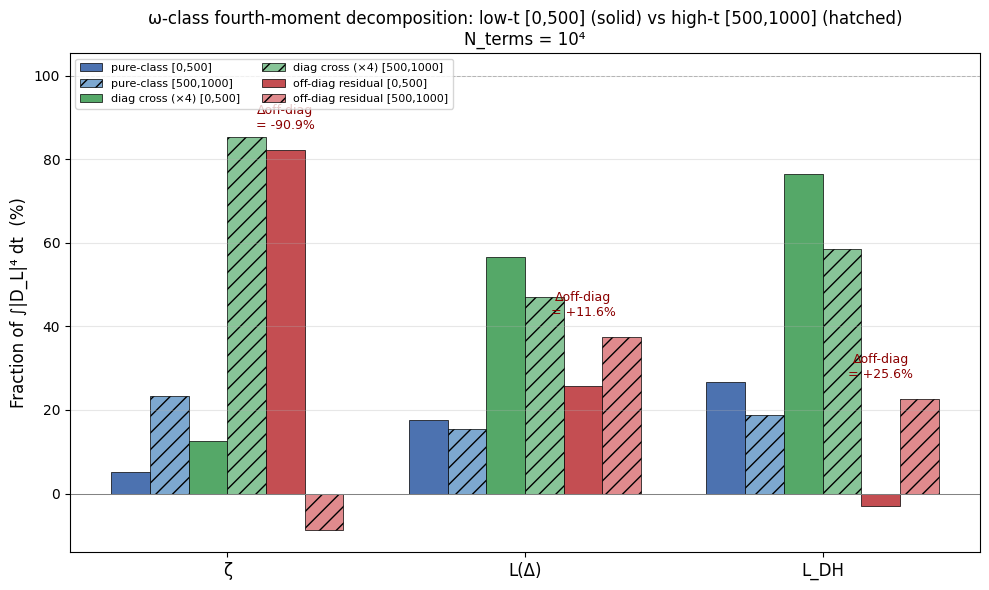

saved /workspace/d91c054a-e339-4ca8-abcb-0fc9bf110f36/fourth_moment_high_t_window_comparison.png


In [30]:
# Final figure: bar chart comparing fractional contributions in [0,500] vs [500,1000]
import matplotlib.pyplot as plt
import numpy as np

labels = ['ζ', 'L(Δ)', 'L_DH']
comps = ['pure-class', 'diag cross (×4)', 'off-diag residual']

old_vals = np.array([
 [r['pure-class (k,k,k,k) %'], r['diag cross (j,j,k,k) %'], r['off-diag %']]
 for _, r in r13_df.iterrows()
])
new_vals = np.array([
 [row['pure-class %'], row['diag cross x4 %'], row['off-diag %']]
 for row in new_rows
])

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(labels))
width = 0.13
colors_old = ['#4c72b0', '#55a868', '#c44e52']
colors_new = ['#7da8d0', '#88c598', '#e08a8d']

for i, comp in enumerate(comps):
 ax.bar(x + (i - 1) * 2*width - width/2, old_vals[:, i], width, label=f'{comp} [0,500]', color=colors_old[i], edgecolor='black', linewidth=0.5)
 ax.bar(x + (i - 1) * 2*width + width/2, new_vals[:, i], width, label=f'{comp} [500,1000]', color=colors_new[i], hatch='//', edgecolor='black', linewidth=0.5)

ax.axhline(0, color='gray', lw=0.7)
ax.axhline(100, color='gray', lw=0.7, ls='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Fraction of ∫|D_L|⁴ dt (%)', fontsize=12)
ax.set_title('ω-class fourth-moment decomposition: low-t [0,500] (solid) vs high-t [500,1000] (hatched)\nN_terms = 10⁴', fontsize=12)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3)

# annotate off-diag residual change
for i, lab in enumerate(labels):
 delta = new_vals[i,2] - old_vals[i,2]
 ax.annotate(f'Δoff-diag\n= {delta:+.1f}%', xy=(x[i]+1.5*width, max(old_vals[i,2], new_vals[i,2])+5),
 ha='center', fontsize=9, color='darkred')

plt.tight_layout()
out_png = '/workspace/d91c054a-e339-4ca8-abcb-0fc9bf110f36/fourth_moment_high_t_window_comparison.png'
plt.savefig(out_png, dpi=140)
plt.show()
print('saved', out_png)


In [31]:
from e14c.filesystem import write_file
mem = open('/workspace/d91c054a-e339-4ca8-abcb-0fc9bf110f36/.prompts/MEMORY.md').read()
append = '''## Context
- 2026-05-31 current task d91c054a-e339-4ca8-abcb-0fc9bf110f36 downloaded prior artifacts from data_storage tag `heron_output`, including:
 - zeta_zeros_5000_dps50.npy (entry id 0d92eb5e-786e-4d85-a2c6-e4ffda854719; provenance task 312ec3f0-48c8-4503-bc9a-5fc7da52253e)
 - ldelta_zeros_2000_dps50.npy (entry id ce702425-59dc-48de-a0c9-7323902af7ef; provenance task b67cd9ec-0872-499f-9b60-9e2dee406719)
 - lchi_zeros_5000_dps50.npy (entry id 265e594e-4508-49b3-aad6-84bd8a4578b0; provenance task 41fabbde-1949-4038-b312-35dc9ba94934)
 - ldh_ckpt_02500.npy (entry id 57f77b40-dd4b-43df-ab74-81c17c782afe; provenance task c7eacfb8-052d-4c79-89db-dce9cc4b7e1d)
 - r13 notebook 8c50938a-4e3e-4a69-89c9-0648c02d1679.ipynb (entry id 9df881cf-9220-470c-9320-2325fae68474)
 - r13 summary JSON/CSV for fourth-moment decomposition (entry ids 15e4abfc-664a-45a7-b8b0-8f994c8764c9 and 6f5ae52b-18be-424c-a9dd-41a5da6b896d)

## Notes
- Reused r13 time-sampling engine for ω-class fourth-moment decomposition with Simpson integration and definition:
 pure = sum_k ∫|S_k|^4 dt; diagonal cross-class = 4*sum_{j<k} ∫|S_j|^2|S_k|^2 dt; off-diagonal residual = total - pure - diagonal cross.
- New analysis for window [500,1000], N_terms=10^4, dt=0.01 completed in this task.
- Saved artifacts:
 - fourth_moment_decomposition_500_1000_vs_0_500.csv
 - fourth_moment_omega_decomposition_T500_1000.json
 - fourth_moment_high_t_window_comparison.png
- Key findings:
 - ζ: total drops from 6.278246e8 on [0,500] to 8.502293e4 on [500,1000]; off-diag fraction changes from +82.2576% to -8.6308%.
 - L(Δ): total rises from 3.303673e4 to 4.540576e4; off-diag fraction changes from +25.8040% to +37.4485%.
 - L_DH: total rises from 1.609392e4 to 2.650750e4; off-diag fraction changes from -3.0609% to +22.5602%.
- Interpretation note: the hypothesis is supported for ζ specifically (off-diagonal residual much smaller in magnitude after removing the t=0 peak), but not uniformly across all three L-functions.
'''
new = mem.replace('## Context\n\n[Fill me in]\n\n## Notes\n\n[Fill me in]', append)
write_file('/workspace/d91c054a-e339-4ca8-abcb-0fc9bf110f36/.prompts/MEMORY.md', new)
print('memory updated')


memory updated
